In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import pandas as pd

# Read your Excel file and assign it to the variable 'stroke'
stroke = pd.read_excel("/content/healthcare-dataset-stroke-data (1).csv (1) (1)22.xlsx")

# (Optional) Save it as CSV if needed later
stroke.to_csv("/content/healthcare-dataset-stroke-data (1).csv (1) (1)22.xlsx", index=False)

# Check first few rows to confirm it's loaded
stroke.head()

,id,Gender,Age,Hypertension,Heart Disease,Ever Married,Work Type,Residence Type,Smoking Status,BMI,glucose_mg_dl,Stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,formerly smoked,36.6,228.69,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,never smoked,NaN,202.21,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,never smoked,32.5,105.92,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,smokes,34.4,171.23,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,never smoked,24.0,174.12,1


In [ ]:
def bmi_category(BMI):
    if BMI < 18.5:
        return 'Underweight'
    elif 18.5 <= BMI < 25:
        return 'Normal'
    elif 25 <= BMI < 30:
        return 'Overweight'
    else:
        return 'Obese'

stroke['bmi_category'] = stroke['BMI'].apply(bmi_category)

In [ ]:
def glucose_category( glucose_mg_dl ):
    if  glucose_mg_dl  < 140:
        return 'Normal'
    elif 140 <=  glucose_mg_dl  < 200:
        return 'Prediabetic'
    else:
        return 'Diabetic'

stroke['glucose_category'] = stroke['glucose_mg_dl'].apply(glucose_category)

In [ ]:
print(stroke['bmi_category'].value_counts())
print(stroke['glucose_category'].value_counts())

bmi_category
Obese          2164
Overweight     1506
Normal         1432
Underweight     383
Name: count, dtype: int64
glucose_category
Normal         4634
Diabetic        448
Prediabetic     403
Name: count, dtype: int64


In [ ]:
import pandas as pd

# ✅ Define mappings with logical medical order
bmi_mapping = {
    'Underweight': 0,
    'Normal': 1,
    'Overweight': 2,
    'Obese': 3
}

glucose_mapping = {
    'Normal': 0,
    'Prediabetic': 1,
    'Diabetic': 2
}

# ✅ Apply mapping to create encoded columns
stroke['bmi_category_encoded'] = stroke['bmi_category'].map(bmi_mapping)
stroke['glucose_category_encoded'] = stroke['glucose_category'].map(glucose_mapping)

# ✅ Check results
print(stroke[['bmi_category','bmi_category_encoded']].drop_duplicates())
print(stroke[['glucose_category','glucose_category_encoded']].drop_duplicates())

    bmi_category  bmi_category_encoded
0          Obese                     3
4         Normal                     1
5     Overweight                     2
230  Underweight                     0
  glucose_category  glucose_category_encoded
0         Diabetic                         2
2           Normal                         0
3      Prediabetic                         1


/tmp/ipykernel_2846/893450929.py:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  stroke['BMI'].fillna(stroke['BMI'].median(), inplace=True)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:20:21] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Class distribution:
 Stroke
0    5205
1     280
Name: count, dtype: int64

Accuracy: 0.9489516864175023
ROC-AUC: 0.8635841224097708


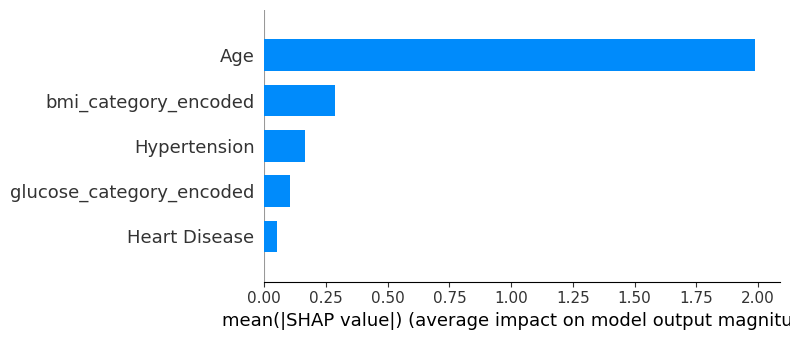

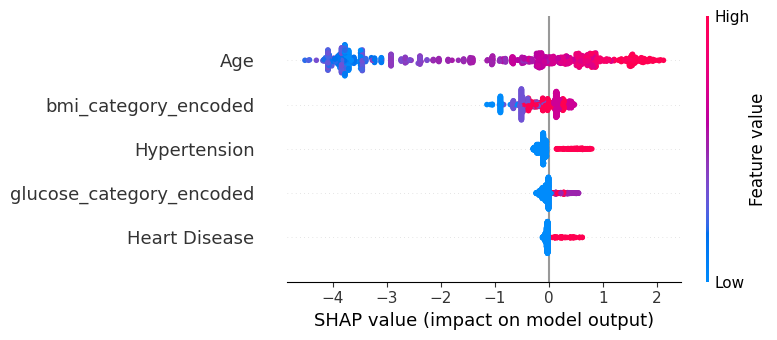

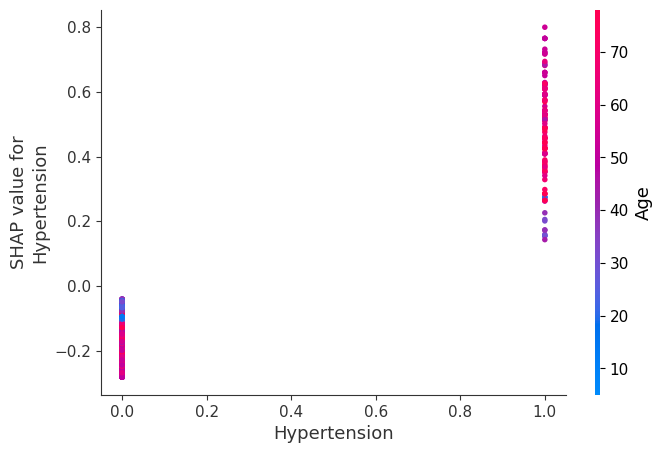

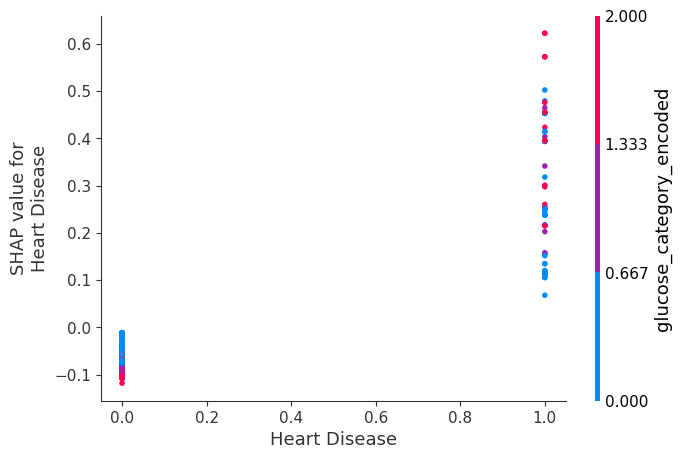

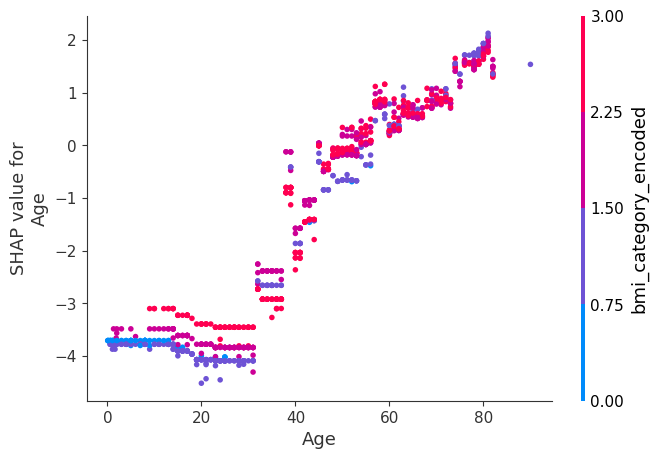

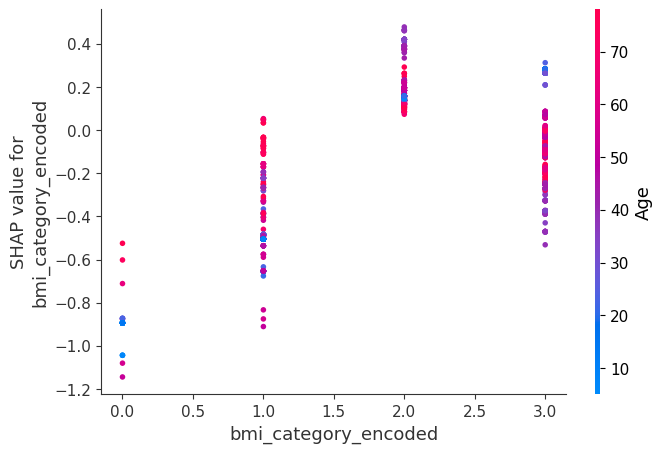

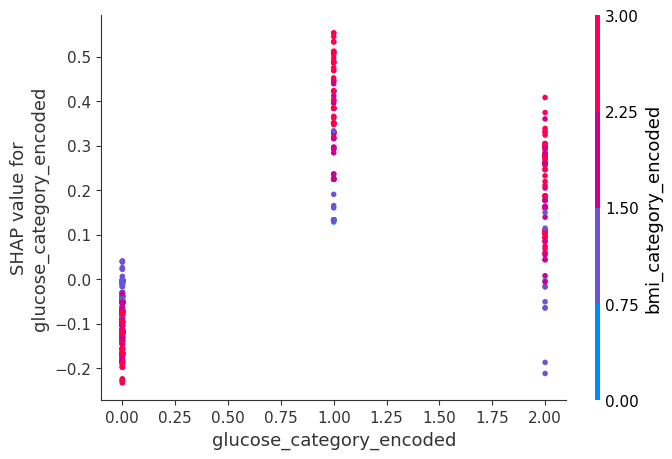

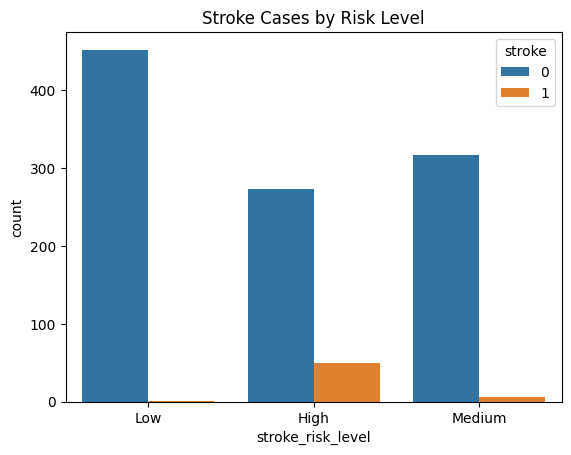


FINAL RISK SCORE OUTPUT:
      stroke_risk_score  stroke_risk_score_scaled stroke_risk_level  stroke
5267          -7.668054                  0.041990               Low       0
450           -2.113220                  0.756280              High       0
2738          -4.842054                  0.405382            Medium       0
2249          -7.694685                  0.038565               Low       0
1658          -1.478596                  0.837885              High       0


In [ ]:
#SHAP analysis by Xgboost
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, roc_auc_score
import shap
import seaborn as sns
import matplotlib.pyplot as plt

# ===========================================
# STEP 0 — CLEAN COLUMNS
# ===========================================
# Remove trailing spaces in column names
stroke.columns = stroke.columns.str.strip()

# Drop empty columns if any
stroke = stroke.drop(columns=[col for col in stroke.columns if 'Unnamed' in col], errors='ignore')

# ===========================================
# STEP 1 — HANDLE MISSING VALUES
# ===========================================
stroke['BMI'].fillna(stroke['BMI'].median(), inplace=True)

# ===========================================
# STEP 2 — FEATURE ENGINEERING
# ===========================================
def bmi_category(BMI):
    if BMI < 18.5:
        return 'Underweight'
    elif 18.5 <= BMI < 25:
        return 'Normal'
    elif 25 <= BMI < 30:
        return 'Overweight'
    else:
        return 'Obese'

stroke['bmi_category'] = stroke['BMI'].apply(bmi_category)

def glucose_category(glucose):
    if glucose < 140:
        return 'Normal'
    elif 140 <= glucose < 200:
        return 'Prediabetic'
    else:
        return 'Diabetic'

stroke['glucose_category'] = stroke['glucose_mg_dl'].apply(glucose_category)

# ===========================================
# STEP 3 — ENCODING CATEGORICAL FEATURES
# ===========================================
bmi_map = {'Underweight':0, 'Normal':1, 'Overweight':2, 'Obese':3}
glucose_map = {'Normal':0, 'Prediabetic':1, 'Diabetic':2}

stroke['bmi_category_encoded'] = stroke['bmi_category'].map(bmi_map)
stroke['glucose_category_encoded'] = stroke['glucose_category'].map(glucose_map)

# ===========================================
# STEP 4 — DEFINE FEATURES AND TARGET
# ===========================================
features = [
    'Hypertension',
    'Heart Disease',
    'Age',
    'bmi_category_encoded',
    'glucose_category_encoded'
]

target = 'Stroke'

# Ensure binary 0/1 target
stroke[target] = stroke[target].apply(lambda x: 1 if x != 0 else 0)

X = stroke[features]
y = stroke[target]

print("Class distribution:\n", y.value_counts())

# ===========================================
# STEP 5 — TRAIN/TEST SPLIT
# ===========================================
# Small minority, so stratify to keep class in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ===========================================
# STEP 6 — TRAIN XGBoost CLASSIFIER
# ===========================================
model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)

model.fit(X_train, y_train)

# ===========================================
# STEP 7 — MODEL EVALUATION
# ===========================================
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

# ===========================================
# STEP 8 — SHAP ANALYSIS
# ===========================================
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Summary plots
shap.summary_plot(shap_values, X_test, plot_type="bar")
shap.summary_plot(shap_values, X_test)

# Dependence plots (safe)
for feat in X_test.columns:
    shap.dependence_plot(feat, shap_values, X_test)

# ===========================================
# STEP 9 — STROKE RISK SCORE CREATION
# ===========================================
stroke_risk_score = shap_values.sum(axis=1) + explainer.expected_value

X_test = X_test.copy()
X_test['stroke_risk_score'] = stroke_risk_score
X_test['stroke'] = y_test.values

# Normalize risk score 0–1
scaler = MinMaxScaler()
X_test['stroke_risk_score_scaled'] = scaler.fit_transform(X_test[['stroke_risk_score']])

# Categorize risk levels
def risk_level(score):
    if score < 0.33:
        return 'Low'
    elif score < 0.66:
        return 'Medium'
    else:
        return 'High'

X_test['stroke_risk_level'] = X_test['stroke_risk_score_scaled'].apply(risk_level)

# ===========================================
# STEP 10 — VISUALIZE RISK LEVELS
# ===========================================
sns.countplot(data=X_test, x='stroke_risk_level', hue='stroke')
plt.title("Stroke Cases by Risk Level")
plt.show()

# Preview results
print("\nFINAL RISK SCORE OUTPUT:")
print(X_test[['stroke_risk_score', 'stroke_risk_score_scaled', 'stroke_risk_level', 'stroke']].head())


/tmp/ipykernel_2846/3791794343.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  stroke['BMI'].fillna(stroke['BMI'].median(), inplace=True)


Class distribution:
 Stroke
0    5205
1     280
Name: count, dtype: int64

Accuracy: 0.9489516864175023
ROC-AUC: 0.8663115822697954


ExactExplainer explainer: 1098it [00:11, 23.87it/s] 


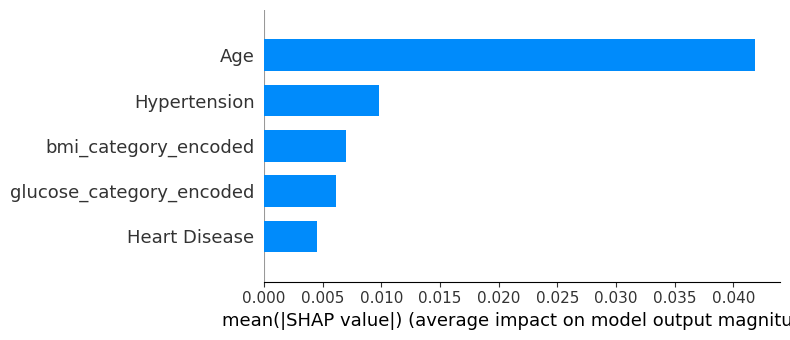

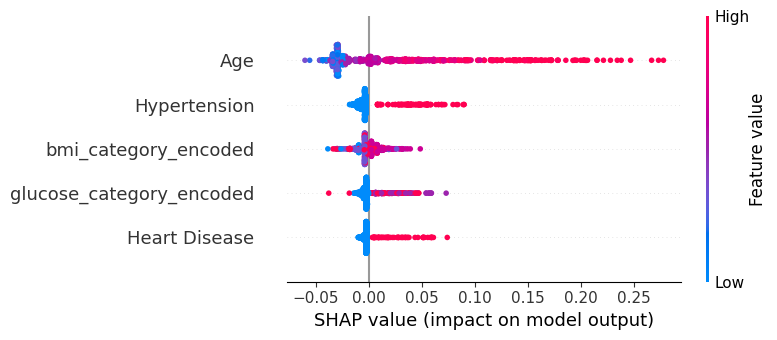

Plotting dependence for: Hypertension


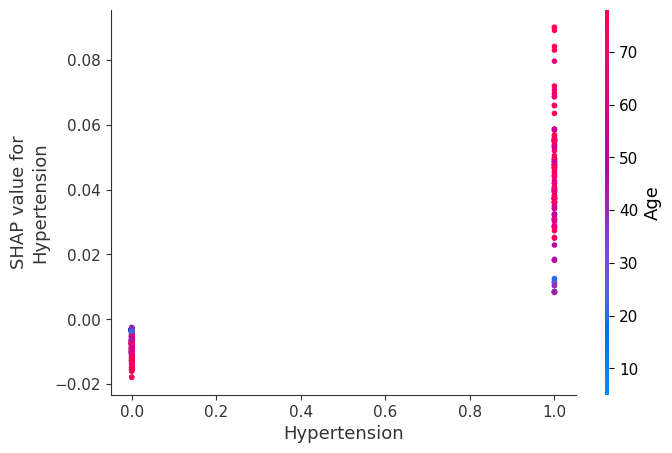

Plotting dependence for: Heart Disease


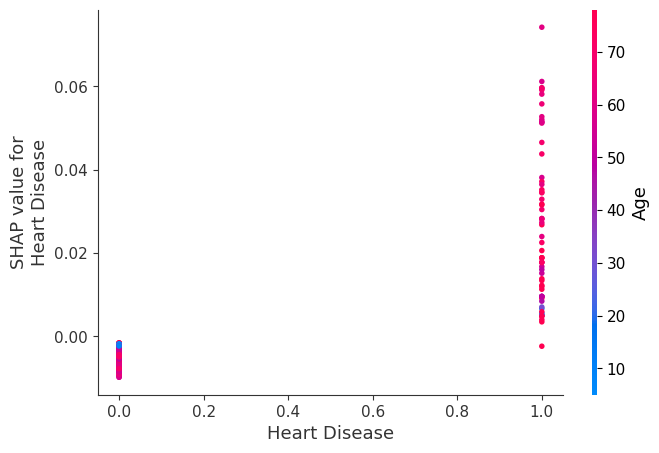

Plotting dependence for: Age


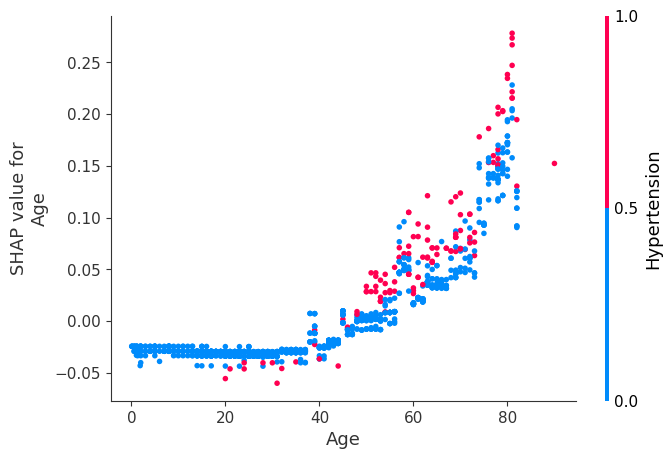

Plotting dependence for: bmi_category_encoded


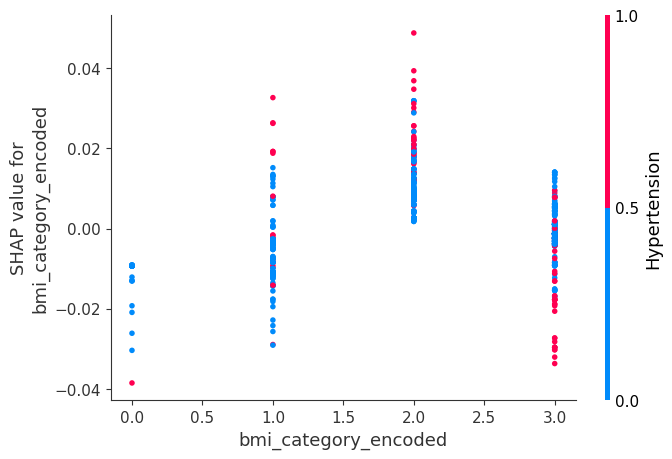

Plotting dependence for: glucose_category_encoded


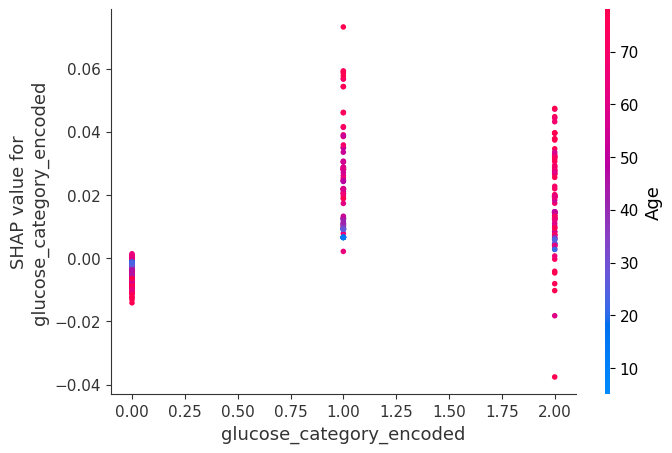

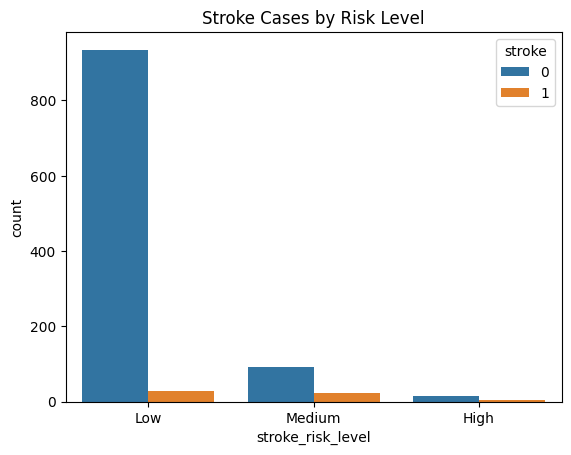

      stroke_risk_score  stroke_risk_score_scaled stroke_risk_level  stroke
5267          -0.039896                  0.000292               Low       0
450            0.067455                  0.241309               Low       0
2738          -0.032534                  0.016820               Low       0
2249          -0.039908                  0.000265               Low       0
1658           0.145276                  0.416027            Medium       0


In [ ]:
#SHAP analysis by Random forest
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
import shap
import seaborn as sns
import matplotlib.pyplot as plt

# ===========================================
# 0 — CLEAN COLUMNS
# ===========================================
stroke.columns = stroke.columns.str.strip()
stroke = stroke.drop(columns=[col for col in stroke.columns if 'Unnamed' in col], errors='ignore')

# ===========================================
# 1 — HANDLE MISSING VALUES
# ===========================================
stroke['BMI'].fillna(stroke['BMI'].median(), inplace=True)

# ===========================================
# 2 — FEATURE ENGINEERING
# ===========================================
def bmi_category(BMI):
    if BMI < 18.5:
        return 'Underweight'
    elif 18.5 <= BMI < 25:
        return 'Normal'
    elif 25 <= BMI < 30:
        return 'Overweight'
    else:
        return 'Obese'

stroke['bmi_category'] = stroke['BMI'].apply(bmi_category)

def glucose_category(glucose):
    if glucose < 140:
        return 'Normal'
    elif 140 <= glucose < 200:
        return 'Prediabetic'
    else:
        return 'Diabetic'

stroke['glucose_category'] = stroke['glucose_mg_dl'].apply(glucose_category)

# ===========================================
# 3 — ENCODING CATEGORICAL FEATURES
# ===========================================
bmi_map = {'Underweight':0, 'Normal':1, 'Overweight':2, 'Obese':3}
glucose_map = {'Normal':0, 'Prediabetic':1, 'Diabetic':2}

stroke['bmi_category_encoded'] = stroke['bmi_category'].map(bmi_map)
stroke['glucose_category_encoded'] = stroke['glucose_category'].map(glucose_map)

# ===========================================
# 4 — FEATURES & TARGET
# ===========================================
features = [
    'Hypertension',
    'Heart Disease',
    'Age',
    'bmi_category_encoded',
    'glucose_category_encoded'
]

target = 'Stroke'
stroke[target] = stroke[target].apply(lambda x: 1 if x != 0 else 0)

X = stroke[features]
y = stroke[target]

print("Class distribution:\n", y.value_counts())

# ===========================================
# 5 — TRAIN/TEST SPLIT
# ===========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ===========================================
# 6 — RANDOM FOREST MODEL
# ===========================================
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

rf_model.fit(X_train, y_train)

# ===========================================
# 7 — MODEL EVALUATION
# ===========================================
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:,1]

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

# ===========================================
# 8 — SHAP EXPLAINER (Safe for RF)
# ===========================================
# Use small background sample for speed
background = shap.sample(X_train, 50)
explainer = shap.Explainer(model.predict_proba, background)
shap_values = explainer(X_test)

# Convert to 2D if 3D
sv = shap_values
if len(sv.values.shape) == 3:
    sv = sv.values[:, :, 1]   # class 1 SHAP values (stroke)

# ===========================================
# 9 — SHAP SUMMARY PLOTS
# ===========================================
shap.summary_plot(sv, X_test, plot_type="bar")
shap.summary_plot(sv, X_test)

# ===========================================
# 10 — SHAP DEPENDENCE PLOTS
# ===========================================
for feat in X_test.columns:
    print(f"Plotting dependence for: {feat}")
    shap.dependence_plot(feat, sv, X_test)

# ===========================================
# 11 — STROKE RISK SCORE
# ===========================================
stroke_risk_score = sv.sum(axis=1)

X_test = X_test.copy()
X_test['stroke_risk_score'] = stroke_risk_score
X_test['stroke'] = y_test.values

# Normalize 0–1
scaler = MinMaxScaler()
X_test['stroke_risk_score_scaled'] = scaler.fit_transform(X_test[['stroke_risk_score']])

# Risk category
def risk_level(x):
    if x < 0.33: return 'Low'
    elif x < 0.66: return 'Medium'
    else: return 'High'

X_test['stroke_risk_level'] = X_test['stroke_risk_score_scaled'].apply(risk_level)

# ===========================================
# 12 — VISUALIZE RISK LEVELS
# ===========================================
sns.countplot(data=X_test, x='stroke_risk_level', hue='stroke')
plt.title("Stroke Cases by Risk Level")
plt.show()

# Preview
print(X_test[['stroke_risk_score', 'stroke_risk_score_scaled', 'stroke_risk_level', 'stroke']].head())


/tmp/ipykernel_2846/1206234265.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  stroke['BMI'].fillna(stroke['BMI'].median(), inplace=True)
/usr/local/lib/python3.12/dist-packages/shap/explainers/_linear.py:123: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


Class distribution:
 Stroke
0    5205
1     280
Name: count, dtype: int64

Accuracy: 0.9498632634457612
ROC-AUC: 0.8604363935776039


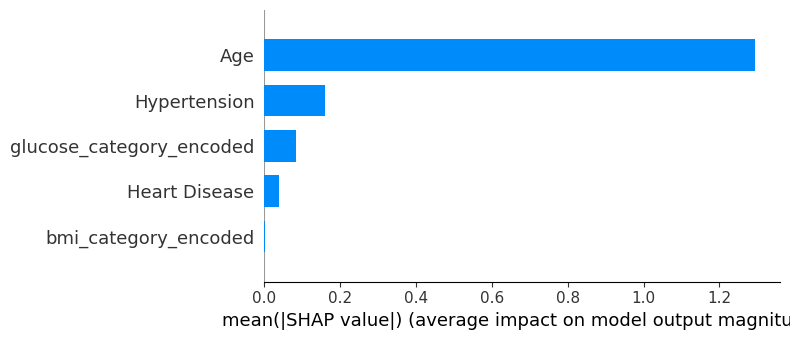

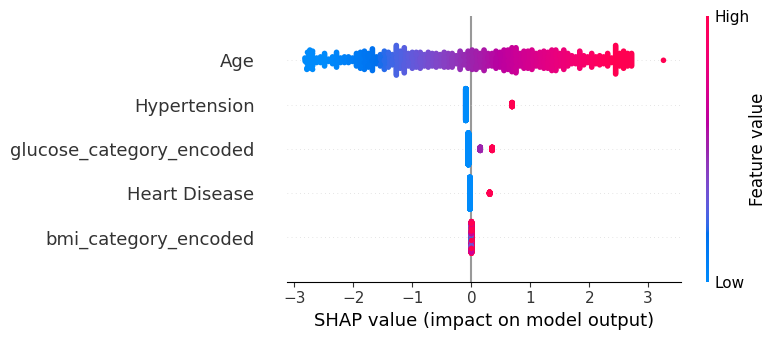

Plotting dependence for: Hypertension


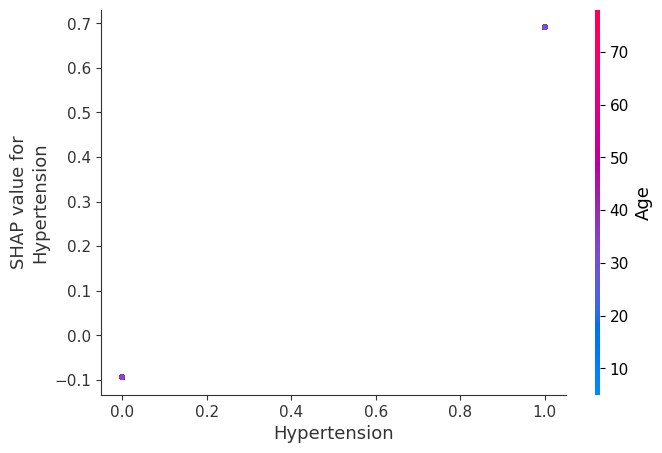

Plotting dependence for: Heart Disease


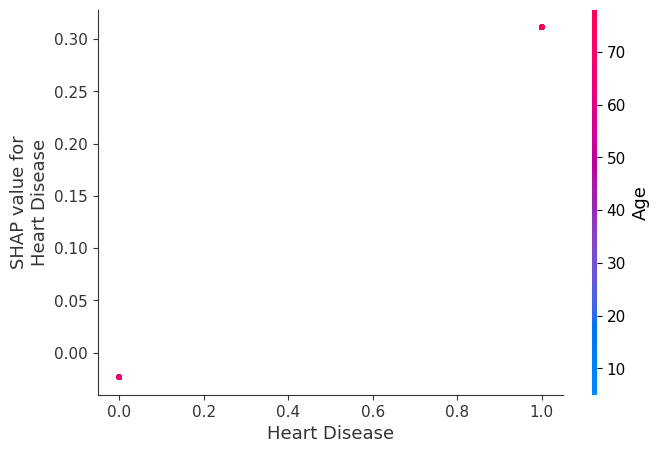

Plotting dependence for: Age


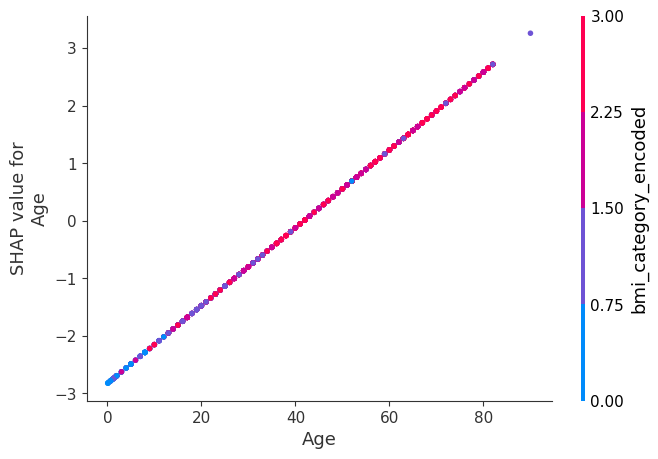

Plotting dependence for: bmi_category_encoded


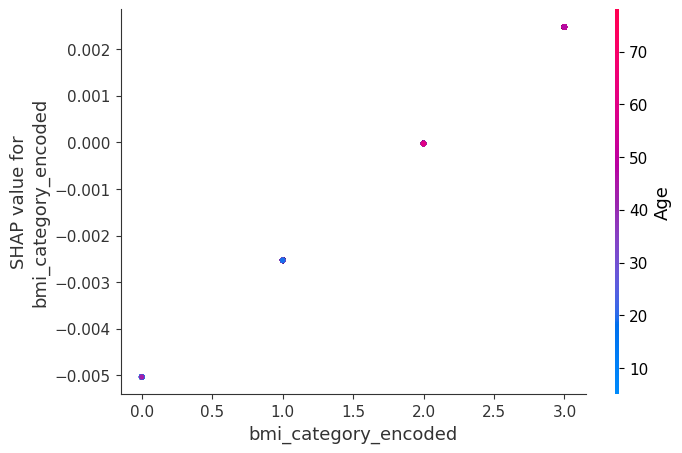

Plotting dependence for: glucose_category_encoded


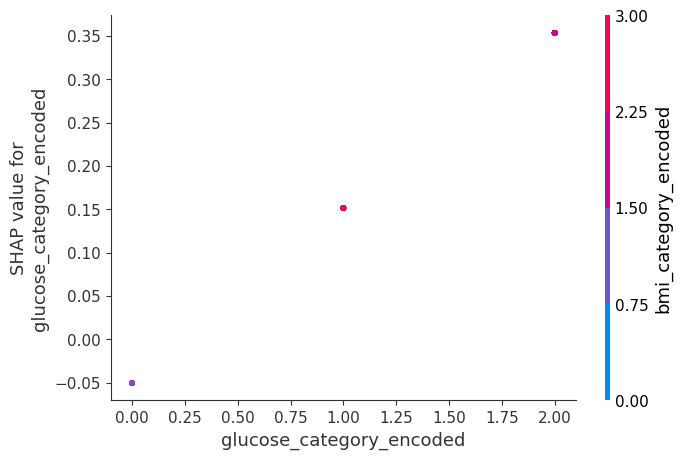

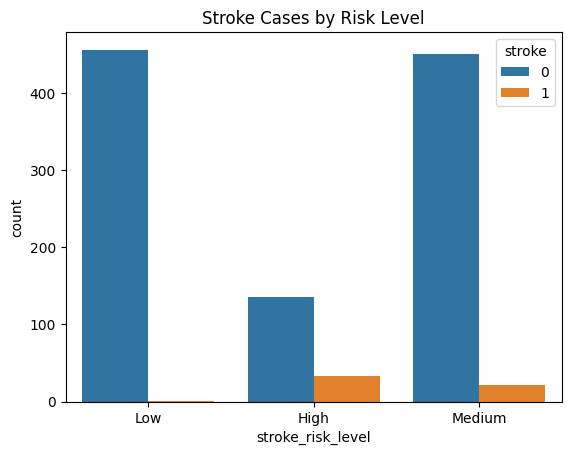

      stroke_risk_score  stroke_risk_score_scaled stroke_risk_level  stroke
5267          -1.442684                  0.204073               Low       0
450            2.208770                  0.683984              High       0
2738          -0.084958                  0.382519            Medium       0
2249          -2.392089                  0.079293               Low       0
1658           1.576486                  0.600883            Medium       0


In [ ]:
#SHAP analysis by Logistic regression
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
import shap
import seaborn as sns
import matplotlib.pyplot as plt

# ===========================================
# 0 — CLEAN COLUMNS
# ===========================================
stroke.columns = stroke.columns.str.strip()
stroke = stroke.drop(columns=[col for col in stroke.columns if 'Unnamed' in col], errors='ignore')

# ===========================================
# 1 — HANDLE MISSING VALUES
# ===========================================
stroke['BMI'].fillna(stroke['BMI'].median(), inplace=True)

# ===========================================
# 2 — FEATURE ENGINEERING
# ===========================================
def bmi_category(BMI):
    if BMI < 18.5:
        return 'Underweight'
    elif 18.5 <= BMI < 25:
        return 'Normal'
    elif 25 <= BMI < 30:
        return 'Overweight'
    else:
        return 'Obese'

stroke['bmi_category'] = stroke['BMI'].apply(bmi_category)

def glucose_category(glucose):
    if glucose < 140:
        return 'Normal'
    elif 140 <= glucose < 200:
        return 'Prediabetic'
    else:
        return 'Diabetic'

stroke['glucose_category'] = stroke['glucose_mg_dl'].apply(glucose_category)

# ===========================================
# 3 — ENCODING CATEGORICAL FEATURES
# ===========================================
bmi_map = {'Underweight':0, 'Normal':1, 'Overweight':2, 'Obese':3}
glucose_map = {'Normal':0, 'Prediabetic':1, 'Diabetic':2}

stroke['bmi_category_encoded'] = stroke['bmi_category'].map(bmi_map)
stroke['glucose_category_encoded'] = stroke['glucose_category'].map(glucose_map)

# ===========================================
# 4 — FEATURES & TARGET
# ===========================================
features = [
    'Hypertension',
    'Heart Disease',
    'Age',
    'bmi_category_encoded',
    'glucose_category_encoded'
]

target = 'Stroke'
stroke[target] = stroke[target].apply(lambda x: 1 if x != 0 else 0)

X = stroke[features]
y = stroke[target]

print("Class distribution:\n", y.value_counts())

# ===========================================
# 5 — TRAIN/TEST SPLIT
# ===========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ===========================================
# 6 — LOGISTIC REGRESSION MODEL
# ===========================================
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# ===========================================
# 7 — MODEL EVALUATION
# ===========================================
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

# ===========================================
# 8 — SHAP EXPLAINER FOR LOGISTIC REGRESSION
# ===========================================
explainer = shap.LinearExplainer(model, X_train, feature_perturbation="interventional")
shap_values = explainer.shap_values(X_test)

# Convert to 2D if 3D (class 1)
sv = shap_values
if len(np.array(sv).shape) == 3:
    sv = sv[:, :, 1]

# ===========================================
# 9 — SHAP SUMMARY PLOTS
# ===========================================
shap.summary_plot(sv, X_test, plot_type="bar")
shap.summary_plot(sv, X_test)

# ===========================================
# 10 — SHAP DEPENDENCE PLOTS
# ===========================================
for feat in X_test.columns:
    print(f"Plotting dependence for: {feat}")
    shap.dependence_plot(feat, sv, X_test)

# ===========================================
# 11 — STROKE RISK SCORE
# ===========================================
stroke_risk_score = sv.sum(axis=1)

X_test = X_test.copy()
X_test['stroke_risk_score'] = stroke_risk_score
X_test['stroke'] = y_test.values

# Normalize 0–1
scaler = MinMaxScaler()
X_test['stroke_risk_score_scaled'] = scaler.fit_transform(X_test[['stroke_risk_score']])

# Risk category
def risk_level(x):
    if x < 0.33: return 'Low'
    elif x < 0.66: return 'Medium'
    else: return 'High'

X_test['stroke_risk_level'] = X_test['stroke_risk_score_scaled'].apply(risk_level)

# ===========================================
# 12 — VISUALIZE RISK LEVELS
# ===========================================
sns.countplot(data=X_test, x='stroke_risk_level', hue='stroke')
plt.title("Stroke Cases by Risk Level")
plt.show()

# Preview
print(X_test[['stroke_risk_score', 'stroke_risk_score_scaled', 'stroke_risk_level', 'stroke']].head())


In [ ]:
#dataframe  create(merge) using Logistic
explainer_all = shap.LinearExplainer(model, X, feature_perturbation="interventional")
shap_values_all = explainer_all.shap_values(X)

# Convert to 2D if needed
sv_all = shap_values_all
if len(np.array(sv_all).shape) == 3:
    sv_all = sv_all[:, :, 1]

# ===========================================
# ADD RISK SCORE TO MAIN DATAFRAME
# ===========================================
# SHAP risk score = expected value + sum of shap values
stroke['stroke_risk_score'] = sv_all.sum(axis=1) + explainer_all.expected_value

# Normalize to 0–1
scaler = MinMaxScaler()
stroke['stroke_risk_score_scaled'] = scaler.fit_transform(
    stroke[['stroke_risk_score']]
)

# Categorize
def risk_level(x):
    if x < 0.33:
        return 'Low'
    elif x < 0.66:
        return 'Medium'
    else:
        return 'High'

stroke['stroke_risk_level'] = stroke['stroke_risk_score_scaled'].apply(risk_level)


/usr/local/lib/python3.12/dist-packages/shap/explainers/_linear.py:123: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


In [ ]:
stroke.head()

,id,Gender,Age,Hypertension,Heart Disease,Ever Married,Work Type,Residence Type,Smoking Status,BMI,glucose_mg_dl,Stroke,bmi_category,glucose_category,bmi_category_encoded,glucose_category_encoded,stroke_risk_score,stroke_risk_score_scaled,stroke_risk_level
0,9046,Male,67.0,0,1,Yes,Private,Urban,formerly smoked,36.600000,228.69,1,Obese,Diabetic,3,2,-1.751407,0.692942,High
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,never smoked,27.623134,202.21,1,Overweight,Diabetic,2,2,-2.494528,0.595273,Medium
2,31112,Male,80.0,0,1,Yes,Private,Rural,never smoked,32.500000,105.92,1,Obese,Normal,3,0,-1.275972,0.755428,High
3,60182,Female,49.0,0,0,Yes,Private,Urban,smokes,34.400000,171.23,1,Obese,Prediabetic,3,1,-3.505563,0.462393,Medium
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,never smoked,24.000000,174.12,1,Normal,Prediabetic,1,1,-0.695827,0.831677,High


/tmp/ipykernel_2846/3610606879.py:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  stroke['BMI'].fillna(stroke['BMI'].median(), inplace=True)
/usr/local/lib/python3.12/dist-packages/shap/explainers/_linear.py:123: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


Class distribution:
 Stroke
0    5205
1     280
Name: count, dtype: int64

Accuracy: 0.9498632634457612
ROC-AUC: 0.8604363935776039

Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.97      1041
           1       1.00      0.02      0.04        56

    accuracy                           0.95      1097
   macro avg       0.97      0.51      0.50      1097
weighted avg       0.95      0.95      0.93      1097

Confusion Matrix:
 [[1041    0]
 [  55    1]]


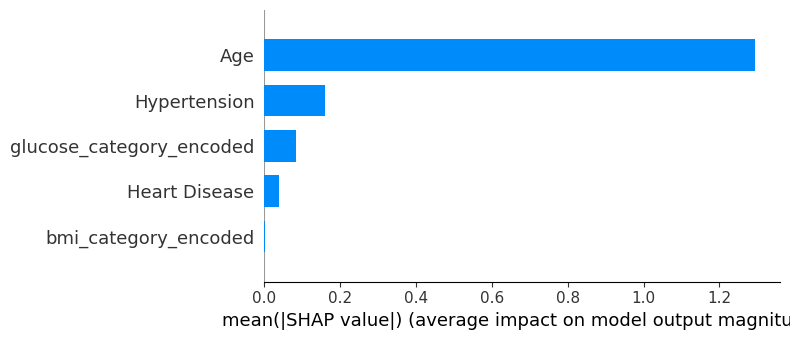

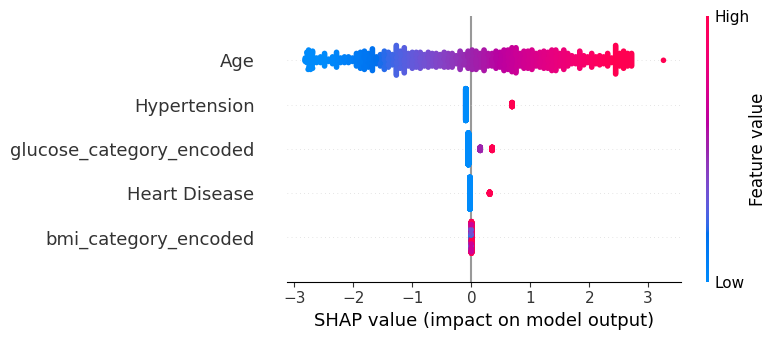

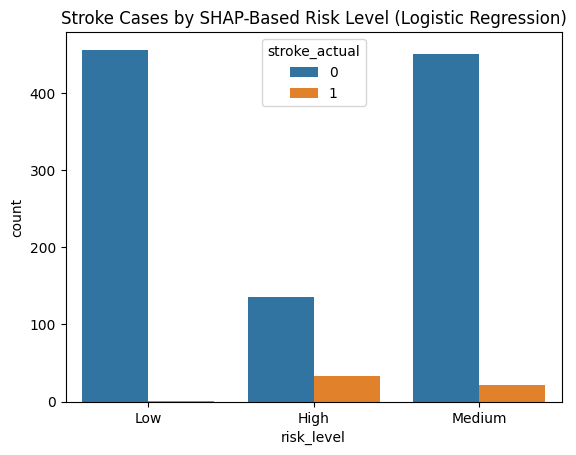

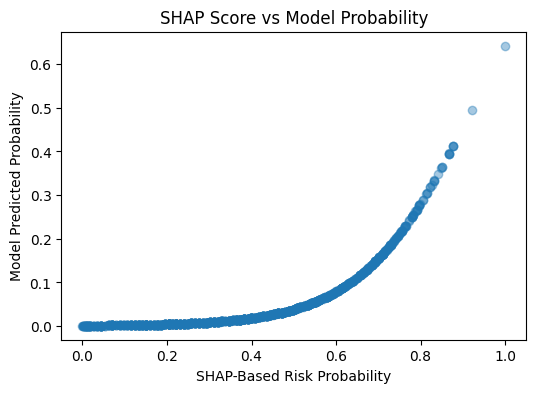

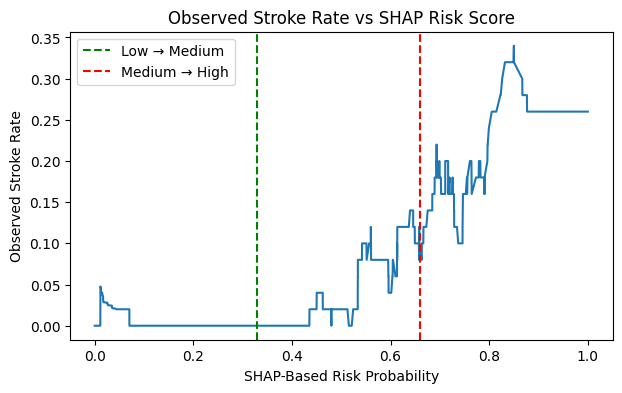


Mean SHAP contribution by risk bin:
 risk_bin
(0.0, 0.1]    0.536612
(0.1, 0.2]    0.373200
(0.2, 0.3]    0.235516
(0.3, 0.4]    0.093336
(0.4, 0.5]    0.158784
(0.5, 0.6]    0.294070
(0.6, 0.7]    0.439401
(0.7, 0.8]    0.570153
(0.8, 0.9]    0.695496
(0.9, 1.0]    0.862778
Name: shap_magnitude, dtype: float64


/tmp/ipykernel_2846/3610606879.py:203: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  shap_bin_summary = X_test.groupby('risk_bin')['shap_magnitude'].mean()


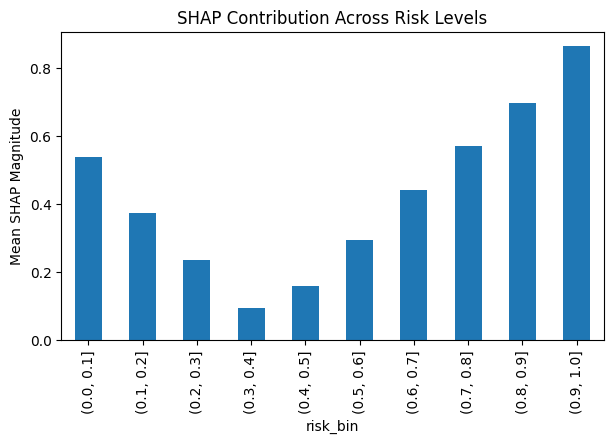


Stroke rate above thresholds:
Threshold ≥ 0.50 → Stroke rate = 0.139
Threshold ≥ 0.60 → Stroke rate = 0.181
Threshold ≥ 0.66 → Stroke rate = 0.196
Threshold ≥ 0.70 → Stroke rate = 0.200
      Hypertension  Heart Disease   Age  bmi_category_encoded  \
5267             0              0  23.0                     1   
450              0              1  72.0                     2   
2738             0              0  43.0                     3   
2249             0              0   9.0                     0   
1658             1              0  53.0                     2   

      glucose_category_encoded  stroke_risk_probability risk_level  \
5267                         0                 0.204073        Low   
450                          0                 0.683984       High   
2738                         0                 0.382519     Medium   
2249                         0                 0.079293        Low   
1658                         1                 0.600883     Medium   

 

In [ ]:
# ===========================================
# IMPORT LIBRARIES
# ===========================================
import pandas as pd
import numpy as np
import shap
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

# ===========================================
# STEP 0 — CLEAN DATA
# ===========================================
stroke.columns = stroke.columns.str.strip()
stroke = stroke.drop(columns=[c for c in stroke.columns if 'Unnamed' in c], errors='ignore')

# ===========================================
# STEP 1 — HANDLE MISSING VALUES
# ===========================================
stroke['BMI'].fillna(stroke['BMI'].median(), inplace=True)

# ===========================================
# STEP 2 — FEATURE ENGINEERING
# ===========================================
def bmi_category(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif bmi < 25:
        return 'Normal'
    elif bmi < 30:
        return 'Overweight'
    else:
        return 'Obese'

stroke['bmi_category'] = stroke['BMI'].apply(bmi_category)

def glucose_category(g):
    if g < 140:
        return 'Normal'
    elif g < 200:
        return 'Prediabetic'
    else:
        return 'Diabetic'

stroke['glucose_category'] = stroke['glucose_mg_dl'].apply(glucose_category)

# ===========================================
# STEP 3 — ENCODING
# ===========================================
bmi_map = {'Underweight':0, 'Normal':1, 'Overweight':2, 'Obese':3}
glucose_map = {'Normal':0, 'Prediabetic':1, 'Diabetic':2}

stroke['bmi_category_encoded'] = stroke['bmi_category'].map(bmi_map)
stroke['glucose_category_encoded'] = stroke['glucose_category'].map(glucose_map)

# ===========================================
# STEP 4 — FEATURES & TARGET
# ===========================================
features = [
    'Hypertension',
    'Heart Disease',
    'Age',
    'bmi_category_encoded',
    'glucose_category_encoded'
]

target = 'Stroke'
stroke[target] = stroke[target].apply(lambda x: 1 if x != 0 else 0)

X = stroke[features]
y = stroke[target]

print("Class distribution:\n", y.value_counts())

# ===========================================
# STEP 5 — TRAIN / TEST SPLIT
# ===========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ===========================================
# STEP 6 — TRAIN LOGISTIC REGRESSION
# ===========================================
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# ===========================================
# STEP 7 — MODEL EVALUATION
# ===========================================
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# ===========================================
# STEP 8 — SHAP EXPLAINABILITY (LOGISTIC)
# ===========================================
explainer = shap.LinearExplainer(
    model,
    X_train,
    feature_perturbation="interventional"
)

shap_values = explainer.shap_values(X_test)

# If returned as 3D, select positive class
if len(np.array(shap_values).shape) == 3:
    shap_values = shap_values[:, :, 1]

# Global importance
shap.summary_plot(shap_values, X_test, plot_type="bar")
shap.summary_plot(shap_values, X_test)

# ===========================================
# STEP 9 — SHAP-BASED RISK SCORE
# ===========================================
stroke_risk_score = shap_values.sum(axis=1) + explainer.expected_value

X_test = X_test.copy()
X_test['stroke_actual'] = y_test.values
X_test['stroke_risk_score'] = stroke_risk_score

# Scale to 0–1
scaler = MinMaxScaler()
X_test['stroke_risk_probability'] = scaler.fit_transform(
    X_test[['stroke_risk_score']]
)

# ===========================================
# STEP 10 — RISK CATEGORIZATION
# ===========================================
def risk_category(p):
    if p < 0.33:
        return 'Low'
    elif p < 0.66:
        return 'Medium'
    else:
        return 'High'

X_test['risk_level'] = X_test['stroke_risk_probability'].apply(risk_category)

# ===========================================
# STEP 11 — VISUALIZE RISK LEVELS
# ===========================================
sns.countplot(data=X_test, x='risk_level', hue='stroke_actual')
plt.title("Stroke Cases by SHAP-Based Risk Level (Logistic Regression)")
plt.show()

# ===========================================
# STEP 12 — SHAP RISK SCORE vs MODEL PROBABILITY
# ===========================================
plt.figure(figsize=(6,4))
plt.scatter(
    X_test['stroke_risk_probability'],
    y_prob,
    alpha=0.4
)
plt.xlabel("SHAP-Based Risk Probability")
plt.ylabel("Model Predicted Probability")
plt.title("SHAP Score vs Model Probability")
plt.show()

# ===========================================
# STEP 13 — THRESHOLD VALIDATION
# ===========================================
X_sorted = X_test.sort_values('stroke_risk_probability')

X_sorted['rolling_stroke_rate'] = (
    X_sorted['stroke_actual']
    .rolling(window=50, min_periods=1)
    .mean()
)

plt.figure(figsize=(7,4))
plt.plot(
    X_sorted['stroke_risk_probability'],
    X_sorted['rolling_stroke_rate']
)
plt.axvline(0.33, color='green', linestyle='--', label='Low → Medium')
plt.axvline(0.66, color='red', linestyle='--', label='Medium → High')
plt.xlabel("SHAP-Based Risk Probability")
plt.ylabel("Observed Stroke Rate")
plt.title("Observed Stroke Rate vs SHAP Risk Score")
plt.legend()
plt.show()

# ===========================================
# STEP 14 — SHAP MAGNITUDE CHECK
# ===========================================
X_test['shap_magnitude'] = np.abs(shap_values).mean(axis=1)

bins = np.linspace(0, 1, 11)
X_test['risk_bin'] = pd.cut(X_test['stroke_risk_probability'], bins)

shap_bin_summary = X_test.groupby('risk_bin')['shap_magnitude'].mean()
print("\nMean SHAP contribution by risk bin:\n", shap_bin_summary)

shap_bin_summary.plot(kind='bar', figsize=(7,4))
plt.ylabel("Mean SHAP Magnitude")
plt.title("SHAP Contribution Across Risk Levels")
plt.show()

# ===========================================
# STEP 15 — NUMERICAL THRESHOLD CHECK
# ===========================================
print("\nStroke rate above thresholds:")
for t in [0.5, 0.6, 0.66, 0.7]:
    rate = X_test[X_test['stroke_risk_probability'] >= t]['stroke_actual'].mean()
    print(f"Threshold ≥ {t:.2f} → Stroke rate = {rate:.3f}")

# ===========================================
# FINAL OUTPUT PREVIEW
# ===========================================
print(
    X_test[
        features +
        ['stroke_risk_probability', 'risk_level', 'stroke_actual']
    ].head()
)

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.8 MB/s eta 0:00:00


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, log_loss, classification_report, confusion_matrix

# ==========================================
# 1 — Prepare Features & Target
# ==========================================
features = [
    'Hypertension',
    'Heart Disease',
    'Age',
    'bmi_category_encoded',
    'glucose_category_encoded'
]

X = stroke[features]
y = stroke['stroke_risk_level']

# Encode target (Low=0, Medium=1, High=2)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# ==========================================
# 2 — Define Models
# ==========================================
models = {
    'Logistic Regression': LogisticRegression(
        multi_class='multinomial', solver='lbfgs', max_iter=1000, class_weight='balanced'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, random_state=42, class_weight='balanced'
    ),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=None, random_state=42, class_weight='balanced'
    ),
    'XGBoost': XGBClassifier(
        objective='multi:softprob', num_class=3, eval_metric='mlogloss',
        learning_rate=0.1, max_depth=4, n_estimators=300, use_label_encoder=False, random_state=42
    ),
    'CatBoost': CatBoostClassifier(
        iterations=300,
        learning_rate=0.1,
        depth=6,
        loss_function='MultiClass',
        random_state=42,
        verbose=0
    ),

    'LightGBM': LGBMClassifier(
        objective='multiclass',
        num_class=3,
        n_estimators=300,
        learning_rate=0.1,
        max_depth=4,
        random_state=42
    ),

     'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVC(
            kernel='rbf',
            probability=True,
            class_weight='balanced',
            random_state=42
        ))
    ])


}

# ==========================================
# 3 — Train & Evaluate All Models
# ==========================================
results = {}

for name, model in models.items():
    print(f"\n==================== {name} ====================")

    # Train
    model.fit(X_train, y_train)

    # Predict labels & probabilities
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    ll = log_loss(y_test, y_proba)

    print(f"Accuracy: {acc:.4f}")
    print(f"Log Loss: {ll:.4f}")
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

    # Save results
    results[name] = {'accuracy': acc, 'log_loss': ll}

# ==========================================
# 4 — Summary of All Models
# ==========================================
import pandas as pd
summary_df = pd.DataFrame(results).T
print("\n====== Summary ======\n", summary_df)



==================== Logistic Regression ====================


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy: 0.9891
Log Loss: 0.0476

Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.98       161
           1       0.99      1.00      1.00       449
           2       1.00      0.98      0.99       487

    accuracy                           0.99      1097
   macro avg       0.98      0.99      0.99      1097
weighted avg       0.99      0.99      0.99      1097

Confusion Matrix:
 [[161   0   0]
 [  0 449   0]
 [  8   4 475]]

==================== Random Forest ====================
Accuracy: 0.9991
Log Loss: 0.0053

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       161
           1       1.00      1.00      1.00       449
           2       1.00      1.00      1.00       487

    accuracy                           1.00      1097
   macro avg       1.00      1.00      1.00      1097
weighted avg       1.00      1.00      1.00      1097

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:21:28] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.9991
Log Loss: 0.0038

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       161
           1       1.00      1.00      1.00       449
           2       1.00      1.00      1.00       487

    accuracy                           1.00      1097
   macro avg       1.00      1.00      1.00      1097
weighted avg       1.00      1.00      1.00      1097

Confusion Matrix:
 [[161   0   0]
 [  0 449   0]
 [  0   1 486]]

==================== CatBoost ====================
Accuracy: 0.9991
Log Loss: 0.0050

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00       161
           1       1.00      1.00      1.00       449
           2       1.00      1.00      1.00       487

    accuracy                           1.00      1097
   macro avg       1.00      1.00      1.00      1097
weighted avg       1.00      1.00      1.00      1097

Con

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, accuracy_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
import numpy as np
import pandas as pd

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'accuracy': make_scorer(accuracy_score),
    'f1_macro': make_scorer(f1_score, average='macro'),
    'f1_weighted': make_scorer(f1_score, average='weighted'),
    'neg_log_loss': 'neg_log_loss'
}

models = {
   'Logistic Regression': LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=1000,
    class_weight='balanced'
),

    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight='balanced'
    ),

    'Decision Tree': DecisionTreeClassifier(
        random_state=42,
        class_weight='balanced'
    ),

    'XGBoost': XGBClassifier(
        objective='multi:softprob',
        num_class=3,
        eval_metric='mlogloss',
        learning_rate=0.1,
        max_depth=4,
        n_estimators=300,
        random_state=42
    ),

     'CatBoost': CatBoostClassifier(
        iterations=300,
        learning_rate=0.1,
        depth=6,
        loss_function='MultiClass',
        random_state=42,
        verbose=0
    ),

    'LightGBM': LGBMClassifier(
        objective='multiclass',
        num_class=3,
        n_estimators=300,
        learning_rate=0.1,
        max_depth=4,
        random_state=42
    ),

     'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVC(
            kernel='rbf',
            probability=True,
            class_weight='balanced',
            random_state=42
        ))
    ])


}

cv_results = {}

for name, model in models.items():
    print(f"\n==================== {name} ====================")

    scores = cross_validate(
        model,
        X,
        y_encoded,
        cv=skf,
        scoring=scoring,
        n_jobs=-1
    )

    log_loss_scores = -scores['test_neg_log_loss']

    acc_mean = scores['test_accuracy'].mean()
    acc_std = scores['test_accuracy'].std()

    f1m_mean = scores['test_f1_macro'].mean()
    f1m_std = scores['test_f1_macro'].std()

    f1w_mean = scores['test_f1_weighted'].mean()
    f1w_std = scores['test_f1_weighted'].std()

    ll_mean = log_loss_scores.mean()
    ll_std = log_loss_scores.std()

    print(f"Accuracy: {acc_mean:.4f} ± {acc_std:.4f}")
    print(f"Macro F1: {f1m_mean:.4f} ± {f1m_std:.4f}")
    print(f"Weighted F1: {f1w_mean:.4f} ± {f1w_std:.4f}")
    print(f"Log Loss: {ll_mean:.4f} ± {ll_std:.4f}")

    cv_results[name] = {
        'Accuracy': acc_mean,
        'Accuracy_std': acc_std,
        'Macro_F1': f1m_mean,
        'Macro_F1_std': f1m_std,
        'Weighted_F1': f1w_mean,
        'Weighted_F1_std': f1w_std,
        'Log_Loss': ll_mean,
        'Log_Loss_std': ll_std
    }

# ===== FINAL SUMMARY TABLE =====
summary_df = pd.DataFrame(cv_results).T
print("\n====== 5-Fold Cross-Validation Summary ======\n")
print(summary_df.round(4))



==================== Logistic Regression ====================
Accuracy: 0.9887 ± 0.0034
Macro F1: 0.9851 ± 0.0045
Weighted F1: 0.9888 ± 0.0034
Log Loss: 0.0484 ± 0.0076

==================== Random Forest ====================
Accuracy: 0.9978 ± 0.0012
Macro F1: 0.9970 ± 0.0016
Weighted F1: 0.9978 ± 0.0012
Log Loss: 0.0086 ± 0.0008

==================== Decision Tree ====================
Accuracy: 0.9976 ± 0.0015
Macro F1: 0.9967 ± 0.0021
Weighted F1: 0.9976 ± 0.0015
Log Loss: 0.0854 ± 0.0534

==================== XGBoost ====================
Accuracy: 0.9976 ± 0.0015
Macro F1: 0.9967 ± 0.0019
Weighted F1: 0.9976 ± 0.0015
Log Loss: 0.0076 ± 0.0046

==================== CatBoost ====================
Accuracy: 0.9976 ± 0.0015
Macro F1: 0.9967 ± 0.0021
Weighted F1: 0.9976 ± 0.0015
Log Loss: 0.0076 ± 0.0027

==================== LightGBM ====================
Accuracy: 0.9980 ± 0.0011
Macro F1: 0.9972 ± 0.0012
Weighted F1: 0.9980 ± 0.0011
Log Loss: 0.0121 ± 0.0083

==================== SVM 


==================== Logistic Regression ====================


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


ROC-AUC: 0.9996
95% CI: (0.9992 - 0.9999)
Brier Score: 0.0129

==================== Decision Tree ====================
ROC-AUC: 0.9995
95% CI: (0.9984 - 1.0000)
Brier Score: 0.0009

==================== Random Forest ====================
ROC-AUC: 1.0000
95% CI: (1.0000 - 1.0000)
Brier Score: 0.0011

==================== XGBoost ====================


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:22:21] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


ROC-AUC: 1.0000
95% CI: (1.0000 - 1.0000)
Brier Score: 0.0009

==================== CatBoost ====================
ROC-AUC: 1.0000
95% CI: (1.0000 - 1.0000)
Brier Score: 0.0009

==================== LightGBM ====================
ROC-AUC: 1.0000
95% CI: (1.0000 - 1.0000)
Brier Score: 0.0007

==================== SVM ====================
ROC-AUC: 0.9996
95% CI: (0.9992 - 0.9999)
Brier Score: 0.0098


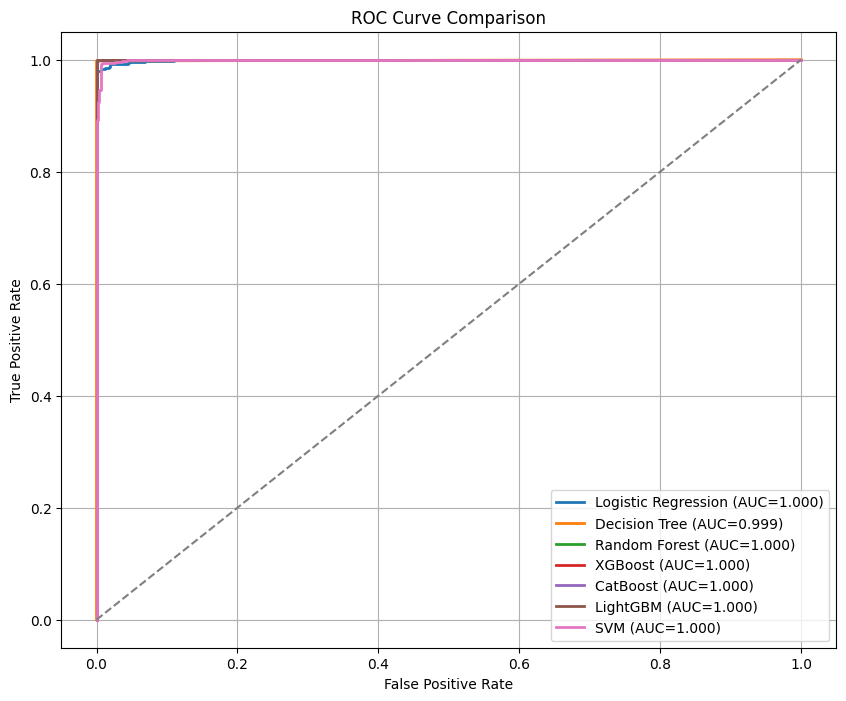

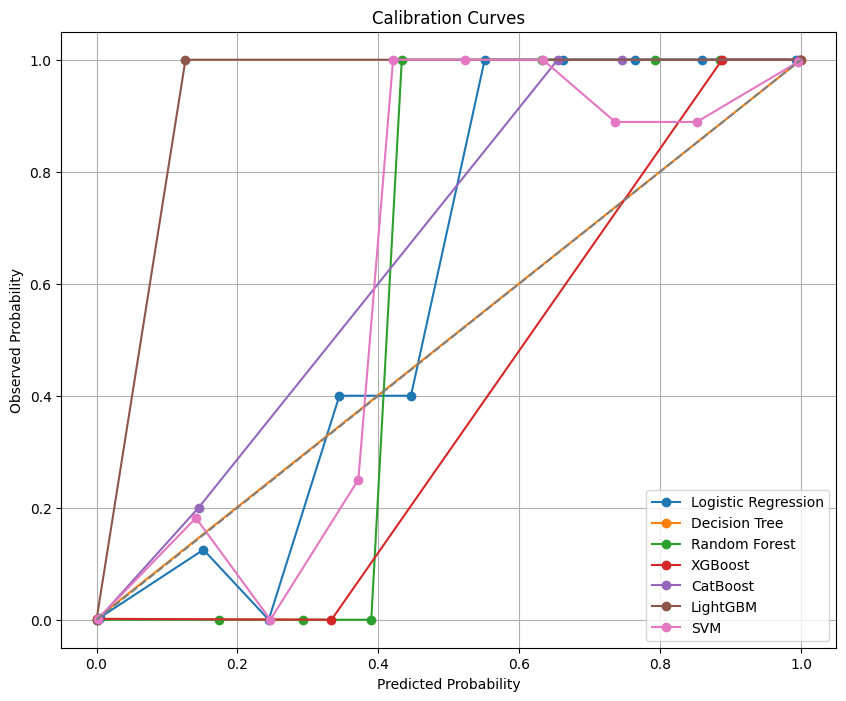


================ FINAL STATISTICAL SUMMARY ================

                     ROC_AUC  CI_Lower  CI_Upper  Brier_Score
Logistic Regression   0.9996    0.9992    0.9999       0.0129
Decision Tree         0.9995    0.9984    1.0000       0.0009
Random Forest         1.0000    1.0000    1.0000       0.0011
XGBoost               1.0000    1.0000    1.0000       0.0009
CatBoost              1.0000    1.0000    1.0000       0.0009
LightGBM              1.0000    1.0000    1.0000       0.0007
SVM                   0.9996    0.9992    0.9999       0.0098


In [ ]:
# ============================================================
# ADVANCED STATISTICAL VALIDATION FOR STROKE RISK MODELS
# ROC CURVE + AUC + CONFIDENCE INTERVAL + CALIBRATION
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    auc,
    brier_score_loss
)

from sklearn.calibration import calibration_curve, CalibrationDisplay

# ============================================================
# 1 — PREPARE FEATURES & TARGET
# ============================================================

features = [
    'Hypertension',
    'Heart Disease',
    'Age',
    'bmi_category_encoded',
    'glucose_category_encoded'
]

X = stroke[features]
y = stroke['stroke_risk_level']

# Encode target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# ============================================================
# 2 — TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# ============================================================
# 3 — DEFINE MODELS
# ============================================================

models = {

    'Logistic Regression': LogisticRegression(
        multi_class='multinomial',
        solver='lbfgs',
        max_iter=1000,
        class_weight='balanced'
    ),

    'Decision Tree': DecisionTreeClassifier(
        random_state=42,
        class_weight='balanced'
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight='balanced'
    ),

    'XGBoost': XGBClassifier(
        objective='multi:softprob',
        num_class=3,
        eval_metric='mlogloss',
        learning_rate=0.1,
        max_depth=4,
        n_estimators=300,
        use_label_encoder=False,
        random_state=42
    ),

       'CatBoost': CatBoostClassifier(
        iterations=300,
        learning_rate=0.1,
        depth=6,
        loss_function='MultiClass',
        random_state=42,
        verbose=0
    ),

    'LightGBM': LGBMClassifier(
        objective='multiclass',
        num_class=3,
        learning_rate=0.1,
        max_depth=4,
        n_estimators=300,
        random_state=42,
        verbosity=-1
    ),

    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVC(
            kernel='rbf',
            probability=True,
            class_weight='balanced',
            random_state=42
        ))
    ])
}

# ============================================================
# 4 — FUNCTION FOR BOOTSTRAP CI
# ============================================================

def bootstrap_auc_ci(y_true, y_prob, n_bootstraps=1000):

    rng = np.random.RandomState(42)
    bootstrapped_scores = []

    for i in range(n_bootstraps):

        indices = rng.randint(0, len(y_prob), len(y_prob))

        if len(np.unique(y_true[indices])) < 2:
            continue

        score = roc_auc_score(
            y_true[indices],
            y_prob[indices],
            multi_class='ovr'
        )

        bootstrapped_scores.append(score)

    sorted_scores = np.array(bootstrapped_scores)
    sorted_scores.sort()

    lower = sorted_scores[int(0.025 * len(sorted_scores))]
    upper = sorted_scores[int(0.975 * len(sorted_scores))]

    return lower, upper

# ============================================================
# 5 — TRAIN MODELS + ROC ANALYSIS
# ============================================================

results = {}

plt.figure(figsize=(10,8))

for name, model in models.items():

    print(f"\n==================== {name} ====================")

    # Train
    model.fit(X_train, y_train)

    # Predict probabilities
    y_prob = model.predict_proba(X_test)

    # Multiclass ROC-AUC
    auc_score = roc_auc_score(
        y_test,
        y_prob,
        multi_class='ovr'
    )

    # Confidence Interval
    ci_lower, ci_upper = bootstrap_auc_ci(
        y_test,
        y_prob
    )

    # Brier Score
    brier = brier_score_loss(
        (y_test == 2).astype(int),
        y_prob[:,2]
    )

    print(f"ROC-AUC: {auc_score:.4f}")
    print(f"95% CI: ({ci_lower:.4f} - {ci_upper:.4f})")
    print(f"Brier Score: {brier:.4f}")

    # Store results
    results[name] = {
        'ROC_AUC': auc_score,
        'CI_Lower': ci_lower,
        'CI_Upper': ci_upper,
        'Brier_Score': brier
    }

    # ROC curve for High-Risk class
    fpr, tpr, _ = roc_curve(
        (y_test == 2).astype(int),
        y_prob[:,2]
    )

    plt.plot(fpr, tpr, lw=2,
             label=f'{name} (AUC={auc_score:.3f})')

# Random line
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(True)
plt.show()

# ============================================================
# 6 — CALIBRATION CURVES
# ============================================================

plt.figure(figsize=(10,8))

for name, model in models.items():

    y_prob = model.predict_proba(X_test)[:,2]

    prob_true, prob_pred = calibration_curve(
        (y_test == 2).astype(int),
        y_prob,
        n_bins=10
    )

    plt.plot(prob_pred, prob_true, marker='o', label=name)

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('Predicted Probability')
plt.ylabel('Observed Probability')
plt.title('Calibration Curves')
plt.legend()
plt.grid(True)
plt.show()

# ============================================================
# 7 — FINAL SUMMARY TABLE
# ============================================================

summary_df = pd.DataFrame(results).T

print("\n================ FINAL STATISTICAL SUMMARY ================\n")
print(summary_df.round(4))

In [ ]:
print("Unique values per feature:")
print(X.nunique())

Unique values per feature:
Hypertension                  2
Heart Disease                 2
Age                         107
bmi_category_encoded          4
glucose_category_encoded      3
dtype: int64


In [ ]:
from sklearn.utils import shuffle
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

y_shuffled = shuffle(y_encoded, random_state=42)

model = RandomForestClassifier(n_estimators=300, random_state=42)

scores = cross_val_score(
    model,
    X,
    y_shuffled,
    cv=5,
    scoring='accuracy'
)

print("Shuffled Accuracy:", scores.mean())

Shuffled Accuracy: 0.4123974475843209


In [ ]:
# ============================================================
# SANITY CHECK: RANDOM LABEL TEST
# ============================================================

from sklearn.utils import shuffle
from sklearn.base import clone
from sklearn.metrics import roc_auc_score
import pandas as pd

print("\n================ SANITY CHECK (RANDOM LABEL TEST) ================\n")

sanity_results = {}

for name, model in models.items():

    print(f"\n--- {name} ---")

    # ========================================================
    # Shuffle ONLY training labels
    # ========================================================

    y_train_random = shuffle(
        y_train,
        random_state=42
    )

    # Fresh model instance
    model_clone = clone(model)

    # Train on random labels
    model_clone.fit(
        X_train,
        y_train_random
    )

    # Predict probabilities
    y_prob = model_clone.predict_proba(X_test)

    # Multiclass ROC-AUC
    auc_random = roc_auc_score(
        y_test,
        y_prob,
        multi_class="ovr"
    )

    sanity_results[name] = auc_random

    print(
        f"{name} AUC (Random Labels): "
        f"{auc_random:.4f}"
    )

# ============================================================
# SUMMARY TABLE
# ============================================================

sanity_df = pd.DataFrame({
    "Random_Label_AUC": sanity_results
})

print("\n================ SANITY CHECK SUMMARY ================\n")
print(sanity_df.round(4))


================ SANITY CHECK (RANDOM LABEL TEST) ================


--- Logistic Regression ---
Logistic Regression AUC (Random Labels): 0.3857

--- Decision Tree ---
Decision Tree AUC (Random Labels): 0.4451

--- Random Forest ---


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Random Forest AUC (Random Labels): 0.4424

--- XGBoost ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:22:53] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost AUC (Random Labels): 0.4308

--- CatBoost ---
CatBoost AUC (Random Labels): 0.4202

--- LightGBM ---
LightGBM AUC (Random Labels): 0.4301

--- SVM ---
SVM AUC (Random Labels): 0.6924

================ SANITY CHECK SUMMARY ================

                     Random_Label_AUC
Logistic Regression            0.3857
Decision Tree                  0.4451
Random Forest                  0.4424
XGBoost                        0.4308
CatBoost                       0.4202
LightGBM                       0.4301
SVM                            0.6924


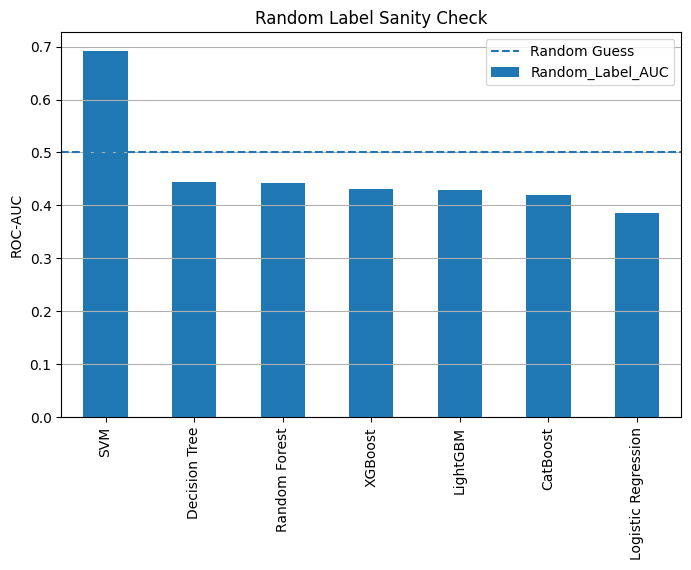

In [ ]:
import matplotlib.pyplot as plt

sanity_df.sort_values(
    "Random_Label_AUC",
    ascending=False
).plot(
    kind="bar",
    figsize=(8,5)
)

plt.axhline(
    y=0.50,
    linestyle="--",
    label="Random Guess"
)

plt.ylabel("ROC-AUC")
plt.title("Random Label Sanity Check")
plt.legend()
plt.grid(axis='y')

plt.show()

In [ ]:
# ============================================================
# FEATURE SHUFFLE SANITY CHECK
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score
from sklearn.utils import shuffle
from sklearn.base import clone

print("\n================ FEATURE SHUFFLE SANITY CHECK ================\n")

feature_shuffle_results = {}

# Convert to DataFrame for safe column-wise shuffling
X_test_df = pd.DataFrame(X_test, columns=features)
X_train_df = pd.DataFrame(X_train, columns=features)

for name, model in models.items():

    print(f"\n--- {name} ---")

    auc_scores = []

    # repeat multiple times for stability
    for seed in [0, 1, 2, 3, 4]:

        # --------------------------------------------------------
        # STEP 1: shuffle each feature column independently
        # --------------------------------------------------------
        X_train_shuffled = X_train_df.copy()
        X_test_shuffled = X_test_df.copy()

        for col in features:
            X_train_shuffled[col] = shuffle(
                X_train_shuffled[col],
                random_state=seed
            )
            X_test_shuffled[col] = shuffle(
                X_test_shuffled[col],
                random_state=seed
            )

        # --------------------------------------------------------
        # STEP 2: train fresh model
        # --------------------------------------------------------
        model_clone = clone(model)

        model_clone.fit(
            X_train_shuffled,
            y_train
        )

        # --------------------------------------------------------
        # STEP 3: predict
        # --------------------------------------------------------
        y_prob = model_clone.predict_proba(X_test_shuffled)

        auc = roc_auc_score(
            y_test,
            y_prob,
            multi_class="ovr"
        )

        auc_scores.append(auc)

    # store mean ± stability
    feature_shuffle_results[name] = {
        "mean_auc": np.mean(auc_scores),
        "std_auc": np.std(auc_scores)
    }

    print(
        f"{name} AUC (Feature Shuffled): "
        f"{np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}"
    )

# ============================================================
# SUMMARY TABLE
# ============================================================

feature_shuffle_df = pd.DataFrame(feature_shuffle_results).T

print("\n================ FEATURE SHUFFLE SUMMARY ================\n")
print(feature_shuffle_df.round(4))


================ FEATURE SHUFFLE SANITY CHECK ================


--- Logistic Regression ---


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

Logistic Regression AUC (Feature Shuffled): 0.9996 ± 0.0000

--- Decision Tree ---
Decision Tree AUC (Feature Shuffled): 0.9995 ± 0.0000

--- Random Forest ---
Random Forest AUC (Feature Shuffled): 1.0000 ± 0.0000

--- XGBoost ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:44:51] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:44:51] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:44:52] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:44:52] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

XGBoost AUC (Feature Shuffled): 1.0000 ± 0.0000

--- CatBoost ---
CatBoost AUC (Feature Shuffled): 1.0000 ± 0.0000

--- LightGBM ---
LightGBM AUC (Feature Shuffled): 1.0000 ± 0.0000

--- SVM ---
SVM AUC (Feature Shuffled): 0.9996 ± 0.0000

================ FEATURE SHUFFLE SUMMARY ================

                     mean_auc  std_auc
Logistic Regression    0.9996      0.0
Decision Tree          0.9995      0.0
Random Forest          1.0000      0.0
XGBoost                1.0000      0.0
CatBoost               1.0000      0.0
LightGBM               1.0000      0.0
SVM                    0.9996      0.0


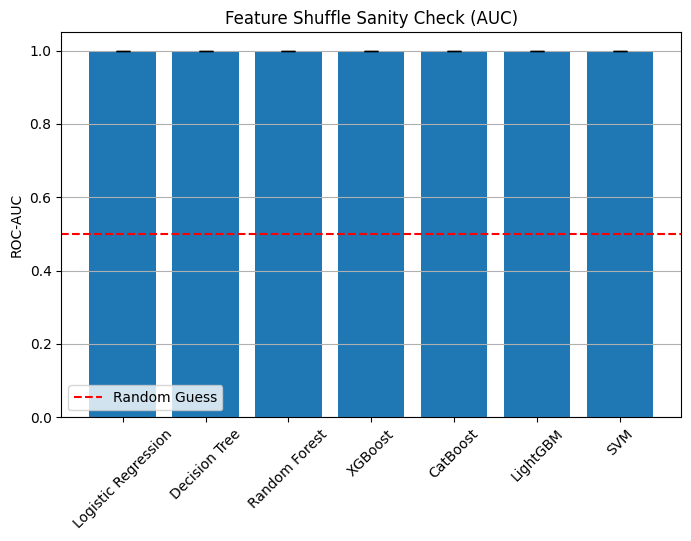

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    feature_shuffle_df.index,
    feature_shuffle_df["mean_auc"],
    yerr=feature_shuffle_df["std_auc"],
    capsize=5
)

plt.axhline(0.5, linestyle="--", color="red", label="Random Guess")

plt.title("Feature Shuffle Sanity Check (AUC)")
plt.ylabel("ROC-AUC")
plt.xticks(rotation=45)
plt.legend()
plt.grid(axis='y')

plt.show()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score
from sklearn.base import clone

print("\n================ FEATURE SHUFFLE SANITY CHECK updated ================\n")

feature_shuffle_results = {}

# convert to DataFrame
X_train_df = pd.DataFrame(X_train, columns=features)
X_test_df = pd.DataFrame(X_test, columns=features)

for name, model in models.items():

    print(f"\n--- {name} ---")

    auc_scores = []

    for seed in [0, 1, 2, 3, 4]:

        rng = np.random.RandomState(seed)

        # copy original data
        X_train_shuffled = X_train_df.copy()
        X_test_shuffled = X_test_df.copy()

        # ========================================================
        # COLUMN-WISE PERMUTATION (SAFE + TRUE FEATURE SHUFFLE)
        # ========================================================
        for col in features:
            X_train_shuffled[col] = rng.permutation(X_train_shuffled[col].values)
            X_test_shuffled[col] = rng.permutation(X_test_shuffled[col].values)

        # ========================================================
        # MODEL HANDLING (SKLEARN vs TABNET)
        # ========================================================

        if name.lower() == "tabnet":

            # TabNet expects numpy arrays
            model_clone = model.__class__(**model.get_params())

            model_clone.fit(
                X_train_shuffled.values,
                y_train,
                eval_set=[(X_test_shuffled.values, y_test)],
                eval_metric=["auc"],
                max_epochs=30,
                patience=10,
                batch_size=256,
                virtual_batch_size=128,
                verbose=0
            )

            y_prob = model_clone.predict_proba(X_test_shuffled.values)

        else:
            # sklearn / boosting models
            model_clone = clone(model)

            model_clone.fit(X_train_shuffled, y_train)

            y_prob = model_clone.predict_proba(X_test_shuffled)

        # ========================================================
        # AUC COMPUTATION
        # ========================================================
        auc = roc_auc_score(
            y_test,
            y_prob,
            multi_class="ovr"
        )

        auc_scores.append(auc)

    # store results
    feature_shuffle_results[name] = {
        "mean_auc": np.mean(auc_scores),
        "std_auc": np.std(auc_scores)
    }

    print(f"{name} AUC (Feature Shuffled): "
          f"{np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}")

# ============================================================
# FINAL SUMMARY TABLE
# ============================================================

feature_shuffle_df = pd.DataFrame(feature_shuffle_results).T

print("\n================ FEATURE SHUFFLE SUMMARY ================\n")
print(feature_shuffle_df.round(4))


================ FEATURE SHUFFLE SANITY CHECK updated ================


--- Logistic Regression ---


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

Logistic Regression AUC (Feature Shuffled): 0.5146 ± 0.0109

--- Decision Tree ---
Decision Tree AUC (Feature Shuffled): 0.5073 ± 0.0140

--- Random Forest ---
Random Forest AUC (Feature Shuffled): 0.5126 ± 0.0190

--- XGBoost ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:24:48] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:24:50] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:24:51] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:24:51] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

XGBoost AUC (Feature Shuffled): 0.5069 ± 0.0103

--- CatBoost ---
CatBoost AUC (Feature Shuffled): 0.5128 ± 0.0147

--- LightGBM ---
LightGBM AUC (Feature Shuffled): 0.5143 ± 0.0108

--- SVM ---
SVM AUC (Feature Shuffled): 0.4934 ± 0.0174

================ FEATURE SHUFFLE SUMMARY ================

                     mean_auc  std_auc
Logistic Regression    0.5146   0.0109
Decision Tree          0.5073   0.0140
Random Forest          0.5126   0.0190
XGBoost                0.5069   0.0103
CatBoost               0.5128   0.0147
LightGBM               0.5143   0.0108
SVM                    0.4934   0.0174


In [ ]:
for col in features:
    print(col, stroke[col].corr(stroke['stroke_risk_level'].astype('category').cat.codes))

Hypertension -0.2202115019807418
Heart Disease -0.21272549566416774
Age -0.013952644190646244
bmi_category_encoded 0.18211273628686211
glucose_category_encoded -0.11695309828242484


In [ ]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd
import numpy as np

mi_scores = mutual_info_classif(X, y_encoded, random_state=42)

mi_df = pd.DataFrame({
    "Feature": features,
    "Mutual_Info": mi_scores
}).sort_values(by="Mutual_Info", ascending=False)

print("\n================ MUTUAL INFORMATION =================\n")
print(mi_df)


================ MUTUAL INFORMATION =================

                    Feature  Mutual_Info
2                       Age     0.877283
3      bmi_category_encoded     0.108198
0              Hypertension     0.082386
4  glucose_category_encoded     0.067935
1             Heart Disease     0.041982


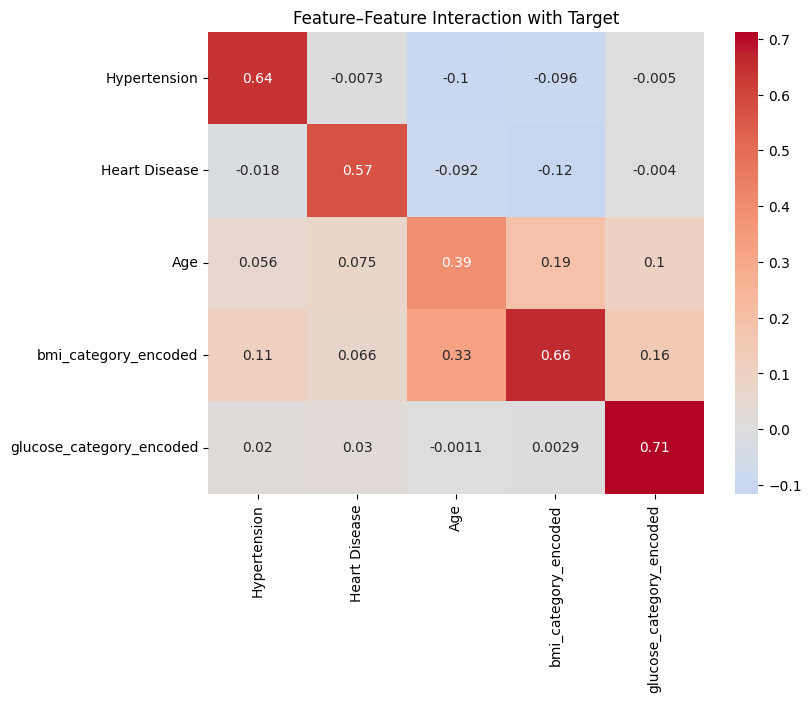

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

df = X.copy()
df["target"] = y_encoded

interaction_matrix = pd.DataFrame(index=features, columns=features)

for f1 in features:
    for f2 in features:

        # interaction strength = correlation between product
        interaction_matrix.loc[f1, f2] = np.corrcoef(
            df[f1],
            df[f2] * df["target"]
        )[0,1]

interaction_matrix = interaction_matrix.astype(float)

plt.figure(figsize=(8,6))
sns.heatmap(interaction_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Feature–Feature Interaction with Target")
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf.fit(X, y_encoded)

result = permutation_importance(
    rf, X, y_encoded,
    n_repeats=10,
    random_state=42
)

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": result.importances_mean
}).sort_values(by="Importance", ascending=False)

print("\n================ PERMUTATION IMPORTANCE =================\n")
print(importance_df)


================ PERMUTATION IMPORTANCE =================

                    Feature  Importance
2                       Age    0.585688
0              Hypertension    0.051869
4  glucose_category_encoded    0.025798
1             Heart Disease    0.012507
3      bmi_category_encoded    0.001933


In [ ]:
# ============================================================
# SINGLE FEATURE ABLATION STUDY (ONE FEATURE AT A TIME)
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.base import clone

print("\n================ SINGLE FEATURE ABLATION STUDY ================\n")

single_feature_results = {}

for feature in features:

    print(f"\n--- Feature: {feature} ---")

    # Use ONLY one feature
    X_single = stroke[[feature]].values

    # Train-test split
    X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
        X_single,
        y_encoded,
        test_size=0.2,
        random_state=42,
        stratify=y_encoded
    )

    single_feature_results[feature] = {}

    for name, model in models.items():

        # clone model (VERY IMPORTANT)
        model_clone = clone(model)

        # train
        model_clone.fit(X_train_s, y_train_s)

        # predictions
        y_pred = model_clone.predict(X_test_s)

        # accuracy
        acc = accuracy_score(y_test_s, y_pred)

        # AUC (multiclass safe)
        try:
            y_prob = model_clone.predict_proba(X_test_s)
            auc = roc_auc_score(
                y_test_s,
                y_prob,
                multi_class="ovr"
            )
        except:
            auc = np.nan

        single_feature_results[feature][name] = {
            "accuracy": acc,
            "auc": auc
        }

        print(f"{name}: Acc = {acc:.4f}, AUC = {auc:.4f}")

# ============================================================
# CONVERT TO DATAFRAME (ACCURACY TABLE)
# ============================================================

acc_df = pd.DataFrame({
    feature: {
        model: single_feature_results[feature][model]["accuracy"]
        for model in models.keys()
    }
    for feature in features
}).T

auc_df = pd.DataFrame({
    feature: {
        model: single_feature_results[feature][model]["auc"]
        for model in models.keys()
    }
    for feature in features
}).T

print("\n================ ACCURACY TABLE =================\n")
print(acc_df.round(4))

print("\n================ AUC TABLE =================\n")
print(auc_df.round(4))


================ SINGLE FEATURE ABLATION STUDY ================


--- Feature: Hypertension ---
Logistic Regression: Acc = 0.4740, AUC = 0.6026
Decision Tree: Acc = 0.4740, AUC = 0.6026


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Random Forest: Acc = 0.4740, AUC = 0.6026


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:56:23] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost: Acc = 0.4740, AUC = 0.6026
CatBoost: Acc = 0.4740, AUC = 0.6026


...

Random Forest: Acc = 0.4430, AUC = 0.5667


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:56:50] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost: Acc = 0.4521, AUC = 0.5757
CatBoost: Acc = 0.4521, AUC = 0.5757


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM: Acc = 0.4521, AUC = 0.5757
SVM: Acc = 0.4430, AUC = 0.5757

================ ACCURACY TABLE =================

                          Logistic Regression  Decision Tree  Random Forest  \
Hypertension                           0.4740         0.4740         0.4740   
Heart Disease                          0.4403         0.4403         0.4403   
Age                                    0.9088         0.9189         0.9189   
bmi_category_encoded                   0.5041         0.5041         0.5041   
glucose_category_encoded               0.4430         0.4430         0.4430   

                          XGBoost  CatBoost  LightGBM     SVM  
Hypertension               0.4740    0.4740    0.4740  0.4740  
Heart Disease              0.4603    0.4603    0.4603  0.4403  
Age                        0.9298    0.9298    0.9298  0.9170  
bmi_category_encoded       0.5834    0.5834    0.5834  0.5041  
glucose_category_encoded   0.4521    0.4521    0.4521  0.4430  

================ AU

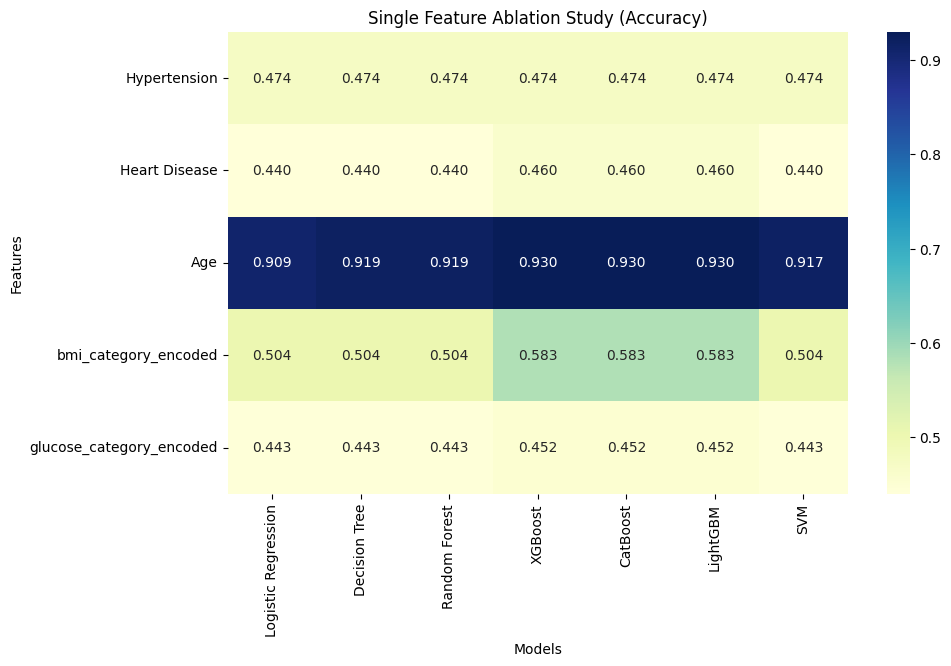

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.heatmap(acc_df, annot=True, cmap="YlGnBu", fmt=".3f")

plt.title("Single Feature Ablation Study (Accuracy)")
plt.xlabel("Models")
plt.ylabel("Features")

plt.show()

In [ ]:
!pip install scikit-posthocs


================ CROSS-VALIDATION (ACCURACY) ================

Logistic Regression: [0.98906108 0.98450319 0.98541477 0.99088423 0.99361896]
Decision Tree: [0.99817685 0.99635369 0.99544211 0.99908842 0.99908842]
Random Forest: [0.99635369 0.99635369 0.99817685 0.99908842 0.99908842]
XGBoost: [0.99635369 0.99544211 0.99817685 0.99908842 0.99908842]
CatBoost: [0.99544211 0.99635369 0.99817685 0.99908842 0.99908842]
LightGBM: [0.99817685 0.99635369 0.99726527 0.99908842 0.99908842]
SVM: [0.96536007 0.96536007 0.96080219 0.9680948  0.97174111]

================ FRIEDMAN TEST ================

Friedman Statistic: 24.3482
P-value: 0.000451

Result: Significant differences exist among models (reject H0)

================ NEMENYI POST-HOC TEST ================

                     Logistic Regression  Decision Tree  Random Forest  \
Logistic Regression             1.000000       0.297637       0.223897   
Decision Tree                   0.297637       1.000000       0.999999   
Random Fores

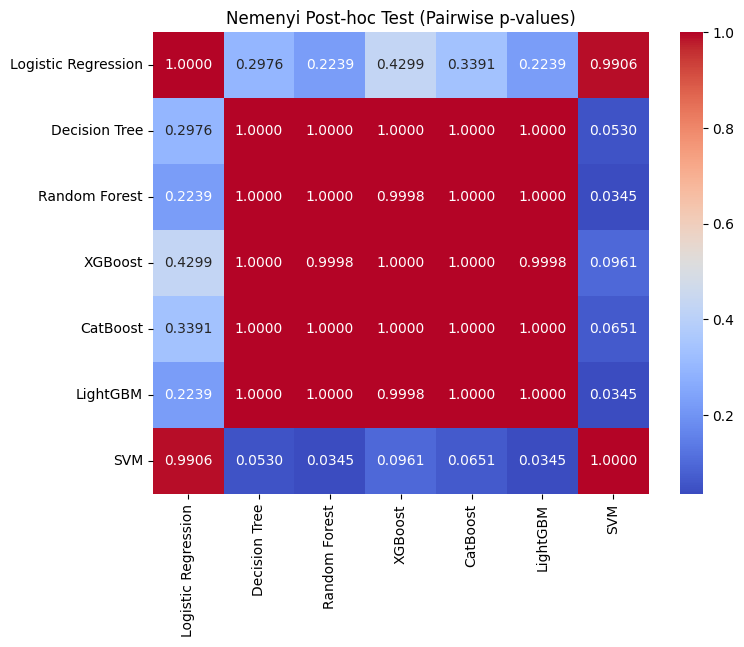


================ MODEL RANKING (MEAN RANKS) ================

Random Forest          2.8
LightGBM               2.8
Decision Tree          3.0
CatBoost               3.1
XGBoost                3.3
Logistic Regression    6.0
SVM                    7.0
dtype: float64


In [ ]:
# ============================================================
# FRIEDMAN TEST + NEMENYI POST-HOC ANALYSIS (FULL PIPELINE)
# ============================================================

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_validate
from scipy.stats import friedmanchisquare
import scikit_posthocs as sp

# ============================================================
# 1 — CROSS-VALIDATION (STORE FOLD-WISE SCORES)
# ============================================================

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores_per_model = {}

print("\n================ CROSS-VALIDATION (ACCURACY) ================\n")

for name, model in models.items():

    scores = cross_validate(
        model,
        X,
        y_encoded,
        cv=skf,
        scoring='accuracy',
        n_jobs=-1,
        return_train_score=False
    )

    cv_scores_per_model[name] = scores['test_score']

    print(f"{name}: {scores['test_score']}")

# ============================================================
# 2 — FRIEDMAN TEST
# ============================================================

print("\n================ FRIEDMAN TEST ================\n")

stat, p_value = friedmanchisquare(*cv_scores_per_model.values())

print(f"Friedman Statistic: {stat:.4f}")
print(f"P-value: {p_value:.6f}")

if p_value < 0.05:
    print("\nResult: Significant differences exist among models (reject H0)")
else:
    print("\nResult: No significant differences among models (fail to reject H0)")

# ============================================================
# 3 — NEMENYI POST-HOC TEST
# ============================================================

print("\n================ NEMENYI POST-HOC TEST ================\n")

# Convert to DataFrame (models as columns)
df_scores = pd.DataFrame(cv_scores_per_model)

nemenyi_matrix = sp.posthoc_nemenyi_friedman(df_scores.values)

nemenyi_matrix.index = df_scores.columns
nemenyi_matrix.columns = df_scores.columns

print(nemenyi_matrix)

# ============================================================
# 4 — HEATMAP VISUALIZATION
# ============================================================

plt.figure(figsize=(8,6))
sns.heatmap(
    nemenyi_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".4f"
)

plt.title("Nemenyi Post-hoc Test (Pairwise p-values)")
plt.show()

# ============================================================
# 5 — RANKING MODELS (MEAN RANKS)
# ============================================================

mean_ranks = df_scores.rank(axis=1, ascending=False).mean()

print("\n================ MODEL RANKING (MEAN RANKS) ================\n")
print(mean_ranks.sort_values())

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, log_loss, classification_report, confusion_matrix

# ==========================================
# 1 — Prepare Features & Target
# ==========================================
features = [
    'Hypertension',
    'Heart Disease',
    'bmi_category_encoded',
    'glucose_category_encoded'
]

X = stroke[features]
y = stroke['stroke_risk_level']

# Encode target (Low=0, Medium=1, High=2)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# ==========================================
# 2 — Define Models
# ==========================================
models = {
    'Logistic Regression': LogisticRegression(
        multi_class='multinomial', solver='lbfgs', max_iter=1000, class_weight='balanced'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, random_state=42, class_weight='balanced'
    ),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=None, random_state=42, class_weight='balanced'
    ),
    'XGBoost': XGBClassifier(
        objective='multi:softprob', num_class=3, eval_metric='mlogloss',
        learning_rate=0.1, max_depth=4, n_estimators=300, use_label_encoder=False, random_state=42
    ),
    'CatBoost': CatBoostClassifier(
        iterations=300,
        learning_rate=0.1,
        depth=6,
        loss_function='MultiClass',
        random_state=42,
        verbose=0
    ),

    'LightGBM': LGBMClassifier(
        objective='multiclass',
        num_class=3,
        n_estimators=300,
        learning_rate=0.1,
        max_depth=4,
        random_state=42
    ),

     'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVC(
            kernel='rbf',
            probability=True,
            class_weight='balanced',
            random_state=42
        ))
    ])


}

# ==========================================
# 3 — Train & Evaluate All Models
# ==========================================
results = {}

for name, model in models.items():
    print(f"\n==================== {name} ====================")

    # Train
    model.fit(X_train, y_train)

    # Predict labels & probabilities
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    ll = log_loss(y_test, y_proba)

    print(f"Accuracy: {acc:.4f}")
    print(f"Log Loss: {ll:.4f}")
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

    # Save results
    results[name] = {'accuracy': acc, 'log_loss': ll}

# ==========================================
# 4 — Summary of All Models
# ==========================================
import pandas as pd
summary_df = pd.DataFrame(results).T
print("\n====== Summary ======\n", summary_df)
